# 17 — TBM-X Optimization & Design Space

Aday tasarımların örnek kısıtlarla filtrelenmesi ve Pareto-benzeri inceleme.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
DATA=Path('data/generated/TBM_X_Large_Design_Dataset_Feasible_v0_1.csv'); OUT=Path('outputs/optimization'); OUT.mkdir(parents=True,exist_ok=True)
df=pd.read_csv(DATA)
required=['ROC_ft_min','stall_speed_kt','L_D','power_margin_kW','MTOW_kg']
missing=[c for c in required if c not in df]; assert not missing, missing

AssertionError: ['L_D']

In [5]:
feasible=df[(df.ROC_ft_min>=800)&(df.stall_speed_kt<=105)&(df.L_D>=12)&(df.power_margin_kW>=50)].copy()
def norm(s):
    return (s-s.min())/(s.max()-s.min()) if s.max()!=s.min() else s*0
feasible['score']=.35*norm(feasible.ROC_ft_min)+.25*norm(feasible.L_D)+.20*(1-norm(feasible.MTOW_kg))+.20*norm(feasible.power_margin_kW)
ranked=feasible.sort_values('score',ascending=False); ranked.head(10)

AttributeError: 'DataFrame' object has no attribute 'L_D'

NameError: name 'feasible' is not defined

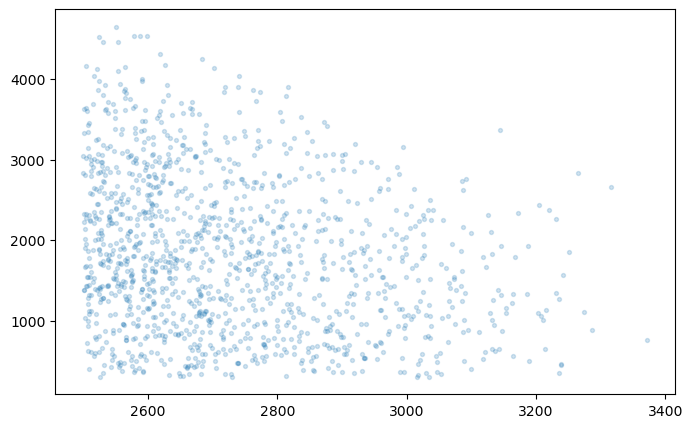

In [6]:
plt.figure(figsize=(8,5)); plt.scatter(df.MTOW_kg,df.ROC_ft_min,s=8,alpha=.2,label='All'); plt.scatter(feasible.MTOW_kg,feasible.ROC_ft_min,s=10,label='Feasible'); plt.xlabel('MTOW [kg]'); plt.ylabel('ROC [ft/min]'); plt.legend(); plt.show()
ranked.to_csv(OUT/'ranked_candidates.csv',index=False)